In [130]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [131]:
import tiktoken
import torch
import torch.nn as nn


In [132]:
class Tokenizatioin:
  def __init__(self):
    self.tokenizer=tiktoken.get_encoding("gpt2")
  def encode(self,text,allowed_special={"<|endoftext|>"}):
    return self.tokenizer.encode(text,allowed_special=allowed_special)
  def decode(self,text):
    return self.tokenizer.decode(text)
  def test_to_token(self,text,allowed_special={"<|endoftext|>"}):
    encode=self.tokenizer.encode(text,allowed_special=allowed_special)
    encode_tensor=torch.tensor([encode])
    return encode_tensor
  def test_token_to_text(self,encode_tensor):
    decode=self.tokenizer.decode(encode_tensor.squeeze(0).tolist())
    return decode

In [133]:
tokenizer = Tokenizatioin()
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [134]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False )

    def forward(self, index):
        batch_size, seq_len = index.shape
        tok_embeds = self.tok_emb(index)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=index.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [135]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))   # gamma
        self.shift = nn.Parameter(torch.zeros(emb_dim))  # beta

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


In [136]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self,x):
    return 0.5*x*(1+torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))*(x+0.044715+torch.pow(x,3))))

In [137]:
class MultiHeadAttention(nn.Module):
    def __init__(self, dim_in, dim_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert dim_out % num_heads == 0, "dim_out must be divisible by num_heads"
        self.d_out = dim_out
        self.num_heads = num_heads
        self.head_dim = dim_out // num_heads

        self.W_query = nn.Linear(dim_in, dim_out, bias=qkv_bias)
        self.W_key = nn.Linear(dim_in, dim_out, bias=qkv_bias)
        self.W_value = nn.Linear(dim_in, dim_out, bias=qkv_bias)
        self.out_proj = nn.Linear(dim_out, dim_out)
        self.dropout = nn.Dropout(dropout)

        # Causal mask (upper triangular to prevent attention to future tokens)
        self.register_buffer(
            "mask", torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, _ = x.shape

        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        # Reshape for multi-head attention
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # Attention scores
        attn_scores = queries @ keys.transpose(-2, -1)
        scale = self.head_dim ** 0.5
        attn_scores /= scale

        # Apply causal mask
        mask_bool = self.mask[:num_tokens, :num_tokens].bool()
        attn_scores.masked_fill_(mask_bool, float("-inf"))

        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Compute attention output
        context_vector = (attn_weights @ values).transpose(1, 2).contiguous()
        context_vector = context_vector.view(b, num_tokens, self.d_out)
        return self.out_proj(context_vector)


In [138]:
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layer=nn.Sequential(nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),GELU(),nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"]))
  def forward(self,x):
    return self.layer(x)

In [139]:
class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.attention=MultiHeadAttention(cfg["emb_dim"],cfg["emb_dim"],cfg["context_length"],cfg["drop_rate"],cfg["n_heads"],cfg["qkv_bias"])
    self.feed_forward=FeedForward(cfg)
    self.layer_norm1=LayerNorm(cfg["emb_dim"])
    self.layer_norm2=LayerNorm(cfg["emb_dim"])
    self.dropout=nn.Dropout(cfg["drop_rate"])
  def forward(self,x):
    shortcut=x
    x=self.layer_norm1(x)
    x=self.attention(x)
    x=self.dropout(x)
    x=x+shortcut
    shortcut=x
    x=self.layer_norm2(x)
    x=self.feed_forward(x)
    x=self.dropout(x)
    x=x+shortcut
    return x

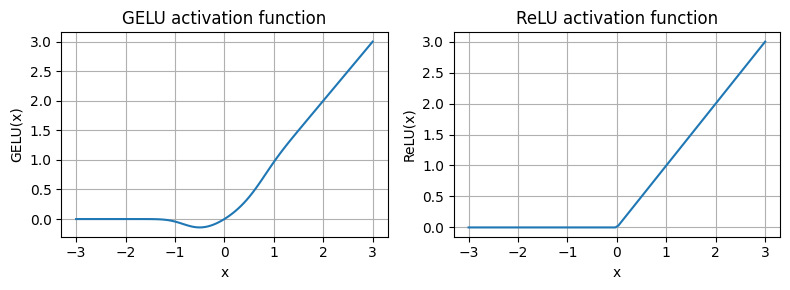

In [140]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()


In [141]:
import torch
import torch.nn as nn

class Embedding(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=cfg['vocab_size'],
                                      embedding_dim=cfg['embedding_dim'])

    def forward(self, x):
        return self.embedding(x)


In [142]:
batch

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

In [143]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (layer): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attention): MultiHeadAttention(
        (

In [144]:
def  generate_text_sample(model,idx,max_new_tokens,context_size):
  for _ in range(max_new_tokens):
    logits=model(idx)
    idx_cond=idx[:,-context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits=logits[:,-1,:]
    probs=torch.softmax(logits,dim=-1)
    idx_next=torch.argmax(probs,dim=-1,keepdim=True)
    idx=torch.cat((idx,idx_next),dim=1)
  return idx

In [145]:
text="hello, i am"
encode=tokenizer.encode(text)
enocded_tensor=torch.tensor([encode])
print(encode)
print(enocded_tensor.shape)
print(enocded_tensor)

[31373, 11, 1312, 716]
torch.Size([1, 4])
tensor([[31373,    11,  1312,   716]])


In [146]:
model.eval()
model=GPTModel(GPT_CONFIG_124M)
out=generate_text_sample(model=model,idx=enocded_tensor,max_new_tokens=6,context_size=GPT_CONFIG_124M['context_length'])
print(out)

tensor([[31373,    11,  1312,   716, 15714, 25557, 37109, 23137, 40276, 39232]])


In [147]:
print(out)
print(out.shape)
print(type(out))


tensor([[31373,    11,  1312,   716, 15714, 25557, 37109, 23137, 40276, 39232]])
torch.Size([1, 10])
<class 'torch.Tensor'>


In [148]:
decoded = tokenizer.decode(out[0].tolist())
print(decoded)


hello, i am distinguishcot Tart waking JollyRepl


random output because the model is not trained

In [149]:
txt="every efforts moves you "
ids=tokenizer.test_to_token(txt)
print(ids)
print(ids.shape)
res=generate_text_sample(model=model,idx=ids,max_new_tokens=6,context_size=GPT_CONFIG_124M['context_length'])
print(res)

tensor([[16833,  4040,  6100,   345,   220]])
torch.Size([1, 5])
tensor([[16833,  4040,  6100,   345,   220, 43122, 11738, 48700, 21778,   870,
         31697]])


In [150]:
res=tokenizer.test_token_to_text(res)
print(res)

every efforts moves you  misconception Rat tf brewinguring331


In [151]:
import urllib.request

path = "https://raw.githubusercontent.com/sakshirautela/LargeLanguageModel/5eb08bdf03d7a1007cf56a76a00aebc41590faa8/model/the-verdict.txt"

with urllib.request.urlopen(path) as response:
    text_data = response.read().decode('utf-8')  # decode bytes to string
print(text_data[:100])

INVESTIGATING EMERGENT GOAL-LIKE BEHAVIOUR IN LARGE
LANGUAGE MODELS USING EXPERIMENTAL ECONOMICS
Ste


In [152]:
with open ("/content/the-verdict.txt","r") as f:
  text_data=f.read()

In [153]:
text_data[:1000]

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would have been Rome or Florence.)\n\n"The height of his glory"--that was what the women called it. I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication. "Of course it\'s going to send the value of my picture \'way up; but I don\'t think of that, Mr. Rickham--the loss to Arrt is all I think of." The word, on Mrs. Thwing\'s lips, multiplied its _rs_ as though they were reflected in an endless vista of mirrors. And it was not only the Mrs. Thwings who mourned. Had not the exquisite Hermia Croft, at the last Grafton Gallery show, stopped me before Gisburn\'s "Moon-dancers" to say, with tears in her eyes: "We shall not look upon its like again"?\n\nWell!--even 

In [154]:
total_character=len(text_data)
total_character

20479

In [155]:
total_tokens=tokenizer.encode(text_data)
len(total_tokens)

5145

In [156]:
from torch.utils.data import Dataset, DataLoader
class GPTDataset(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt)
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [157]:
def create_dataloader_v1(txt, tokenizer, batch_size=2, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Create dataset
    dataset = GPTDataset(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

perform train test split

In [158]:
train_ration=0.9
split_idx=int(train_ration*len(text_data))
train_data=text_data[:split_idx]
test_data=text_data[split_idx:]

train_loader=create_dataloader_v1(train_data, tokenizer)
test_loader=create_dataloader_v1(test_data, tokenizer)

In [159]:
print("Train loader")
for x,y in train_loader:
    print(x.shape,y.shape)
print("Test loader")
for x,y in test_loader:
    print(x.shape,y.shape)

Train loader
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
Test loader
torch.Size([2, 256]) torch.Size([2, 256])


calculating batch loss

In [160]:
def calc_loss_batch(input_batch,target_batch,model,device):
  input_batch=input_batch.to(device)
  target_batch=target_batch.to(device)
  logits=model(input_batch)
  loss=torch.nn.functional.cross_entropy(logits.flatten(0,1),target_batch.flatten())
  return loss

def calc_loss_loader(data_loader,model,device,num_batches=None):
  total_loss=0
  if len(data_loader) == 0:
    return float('nan')
  elif num_batches is None:
    num_batches=len(data_loader)
  else :
    num_batches=min(num_batches,len(data_loader))
  for i , (input_batch,target_batch) in enumerate(data_loader):
    if i>=num_batches:
      break
    loss=calc_loss_batch(input_batch,target_batch,model,device)
    total_loss+=loss.item()
  return total_loss/num_batches

In [161]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
train_loss=calc_loss_loader(train_loader,model,device,num_batches=1)
test_loss=calc_loss_loader(test_loader,model,device,num_batches=1)
print(train_loss)
print(test_loss)

10.975912094116211
11.015212059020996


prediction validation


In [162]:
def evalutae_model(model,train, test, device,eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss=calc_loss_loader(train,model,device,eval_iter)
    test_loss=calc_loss_loader(test,model,device,eval_iter)
    model.train()
  return train_loss,test_loss

In [163]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    with torch.no_grad():
        for i, (input_batch, target_batch) in enumerate(data_loader):
            if i >= num_batches:
                break

            input_batch, target_batch = input_batch.to(device), target_batch.to(device)
            logits = model(input_batch)  # [batch_size, seq_len, vocab_size]

            predicted_labels = torch.argmax(logits, dim=-1)  # [batch_size, seq_len]

            correct_predictions += (predicted_labels == target_batch).sum().item()
            num_examples += target_batch.numel()  # count all tokens in the batch

    return correct_predictions / num_examples if num_examples > 0 else 0


In [164]:
def simple_training_module(model, train, test, optimizer, device,
                           num_epochs, eval_freq, eval_iter):
    train_losses, test_losses ,train_accs, val_accs = [], [], [], []
    token_seen, global_step = 0, 0

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()

            token_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
              train_loss, test_loss = evalutae_model(model,train, test, device,eval_iter)
              train_losses.append(train_loss)
              test_losses.append(test_loss)
              print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {test_loss:.3f}")

        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, test_losses, train_accs, val_accs, token_seen

In [165]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, train_accs, val_accs, examples_seen = simple_training_module(
    model, train_loader, test_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Training accuracy: 6.41% | Validation accuracy: 5.08%
Training accuracy: 7.42% | Validation accuracy: 6.05%
Ep 3 (Step 000050): Train loss 7.134, Val loss 7.563
Training accuracy: 9.10% | Validation accuracy: 6.45%
Training accuracy: 10.55% | Validation accuracy: 6.64%
Training accuracy: 16.02% | Validation accuracy: 8.40%
Ep 6 (Step 000100): Train loss 5.180, Val loss 6.411
Training accuracy: 21.09% | Validation accuracy: 12.30%
Training accuracy: 23.91% | Validation accuracy: 12.30%
Training accuracy: 30.27% | Validation accuracy: 14.06%
Ep 9 (Step 000150): Train loss 3.810, Val loss 6.052
Training accuracy: 36.25% | Validation accuracy: 13.09%
Training accuracy: 40.62% | Validation accuracy: 12.50%
Training completed in 0.58 minutes.


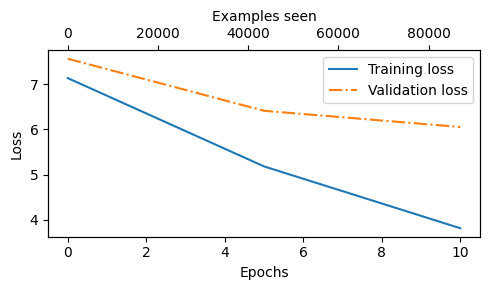

In [169]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

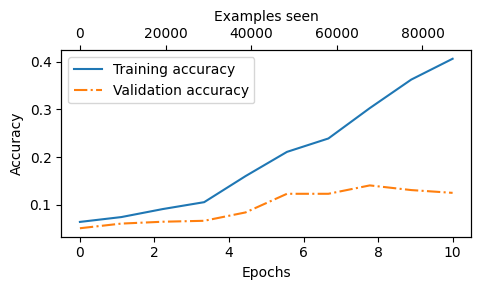

In [170]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

In [171]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(test_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 40.97%
Validation accuracy: 12.50%
Test accuracy: 12.70%


In [174]:
torch.save(model.state_dict(), "model.pth")
model.load_state_dict(torch.load( "model.pth", weights_only=True))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (layer): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attention): MultiHeadAttention(
        (